In [1]:
import numpy as np
import matplotlib . pyplot as plt
import os

In [3]:
np. random . seed (2025)
n, p, k = 500 , 50, 8
sigma = 1.0

m = 10
Z = np. random . randn (n, m)
A = np. random . randn (m, p) * 0.8
X = Z.dot(A) + 0.1 * np. random . randn (n, p)

w_true = np. zeros (p)
w_true [:k] = np. linspace (5.0 , 1.0 , k) * np. random . choice ([1 , -1], k)
y = X.dot( w_true ) + sigma * np. random . randn (n)

idx = np. random . permutation (n)
train_idx , test_idx = idx [:350] , idx [350:]
X_train , y_train = X[ train_idx ], y[ train_idx ]
X_test , y_test = X[ test_idx ], y[ test_idx ]

def ridge_closed_form (X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

def ridge_objective (X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)
    

def ridge_grad (X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent (X, y, lam , s, alpha , beta ):
    w = np.zeros(X.shape[1])
    obj_values = []

    for _ in range(1000):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size
        w = w - t * grad
        obj_values.append(ridge_objective(X, y, w, lam))
    return w, obj_values

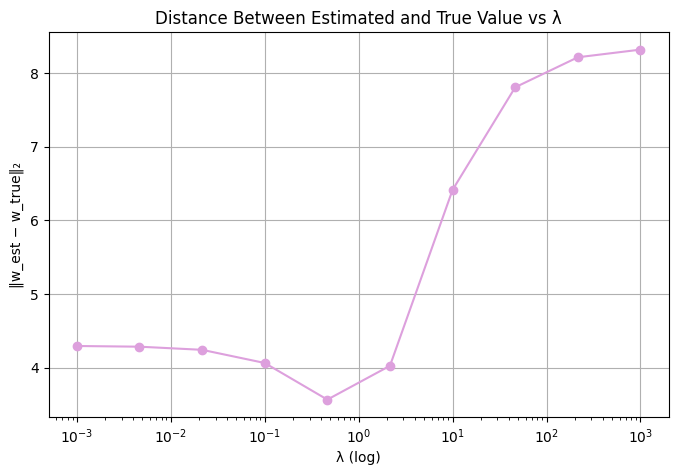

In [22]:
lambdas = np.logspace(-3, 3, 10)
distances = []

for lam in lambdas:
    w_est = ridge_closed_form(X_train, y_train, lam)
    dist = np.linalg.norm(w_est - w_true)
    distances.append(dist)

plt.figure(figsize=(8,5))
plt.semilogx(lambdas, distances, '-o', color='plum')
plt.xlabel("λ (log)")
plt.ylabel("‖w_est − w_true‖₂")
plt.title("Distance Between Estimated and True Value vs λ")
plt.grid(True)
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "lambda10.png")


plt.savefig(downloads_path, dpi=1200)
plt.show()

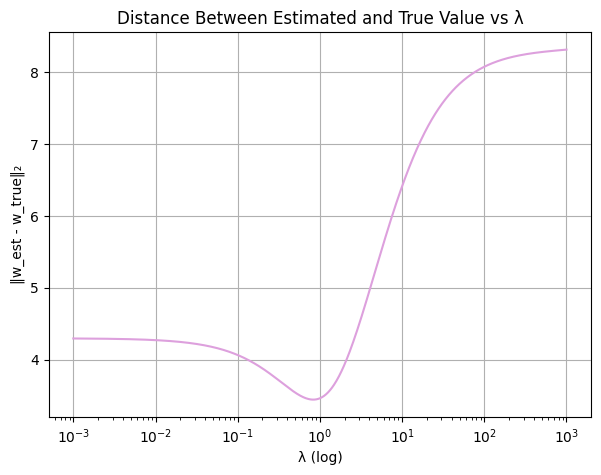

In [ ]:
lambdas = np.logspace(-3, 3, 1000)  
distances = []

for lam in lambdas:
    w_est = ridge_closed_form(X_train, y_train, lam)
    dist = np.linalg.norm(w_est - w_true)  
    distances.append(dist)

plt.figure(figsize=(7,5))
plt.semilogx(lambdas, distances,  color='plum')
plt.xlabel('λ (log)')
plt.ylabel('‖w_est - w_true‖₂')
plt.title("Distance Between Estimated and True Value vs λ")
plt.grid(True)
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "lambda1000.png")


plt.savefig(downloads_path, dpi=1200)
plt.show()

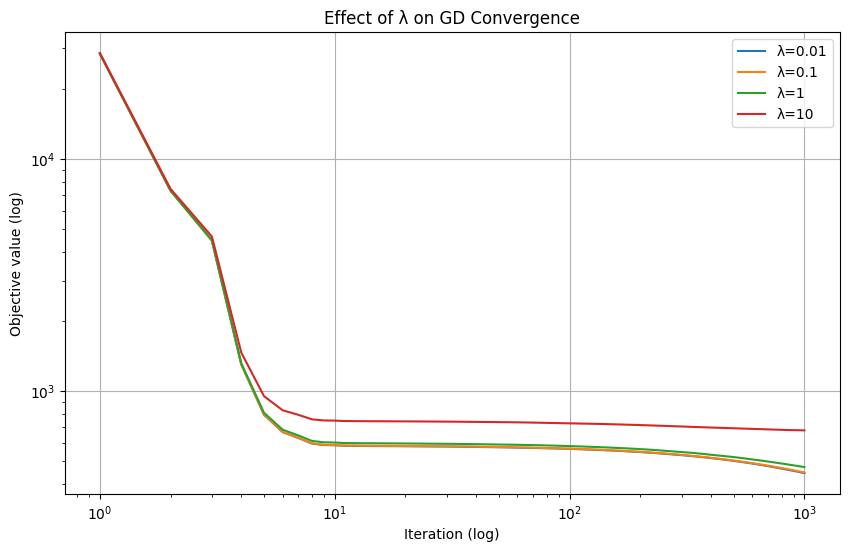

In [8]:
lambdas = [0.01, 0.1, 1, 10]

plt.figure(figsize=(10,6))

for lam in lambdas:
    w_gd, obj_values = gradient_descent(X_train, y_train, lam, s=1.0, alpha=0.01, beta=0.5)
    it = np.arange(1, len(obj_values)+1)
    plt.plot(it, obj_values, label=f"λ={lam}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Iteration (log)")
plt.ylabel("Objective value (log)")
plt.grid(True)
plt.title("Effect of λ on GD Convergence")
plt.legend()
plt.show()